## Task 1

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('Dataset.csv')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5789 entries, 0 to 5788
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Participant_ID          5789 non-null   int64  
 1   survey_date             5789 non-null   object 
 2   region                  5774 non-null   object 
 3   country                 5786 non-null   object 
 4   ip_latitude             5789 non-null   float64
 5   ip_longitude            5789 non-null   float64
 6   gender                  5789 non-null   object 
 7   age                     5789 non-null   object 
 8   height                  5789 non-null   int64  
 9   weight                  5789 non-null   int64  
 10  bmi                     5789 non-null   float64
 11  blood_type              5689 non-null   object 
 12  insurance               4497 non-null   object 
 13  income                  4636 non-null   object 
 14  smoking                 5753 non-null   

In [2]:
# Data type
df['survey_date'] = pd.to_datetime(df['survey_date'], errors='coerce')

df['height'] = df['height'].astype(float)
df['weight'] = df['weight'].astype(float)

insurance_map = {'yes': 1, 'no': 0, 'unknown': np.nan}
df['insurance'] = df['insurance'].map(insurance_map)

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5789 entries, 0 to 5788
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Participant_ID          5789 non-null   int64         
 1   survey_date             4874 non-null   datetime64[ns]
 2   region                  5774 non-null   object        
 3   country                 5786 non-null   object        
 4   ip_latitude             5789 non-null   float64       
 5   ip_longitude            5789 non-null   float64       
 6   gender                  5789 non-null   object        
 7   age                     5789 non-null   object        
 8   height                  5789 non-null   float64       
 9   weight                  5789 non-null   float64       
 10  bmi                     5789 non-null   float64       
 11  blood_type              5689 non-null   object        
 12  insurance               4166 non-null   float64 

## Task 2

In [4]:
for col in df.columns:
    print(f"\n======================{col}=======================")

    print(df[col].describe())
    print("\n --------------------------------------------------")
    print(df[col].value_counts().head(10))
    print("\n --------------------------------------------------")
    print(df[col].unique())


======================Participant_ID=======================
count    5.789000e+03
mean     1.647650e+08
std      2.709376e+08
min      1.968528e+06
25%      3.371715e+07
50%      6.083679e+07
75%      8.598482e+07
max      8.775394e+08
Name: Participant_ID, dtype: float64

 --------------------------------------------------
Participant_ID
877539423    1
862217754    1
2363592      1
2570172      1
2812446      1
2867850      1
2955354      1
2970666      1
3005748      1
71583534     1
Name: count, dtype: int64

 --------------------------------------------------
[862217754   2363592   2570172 ... 863671635 863783472 877539423]

======================survey_date=======================
count                             4874
mean     2020-05-25 08:34:39.934345472
min                2020-01-04 00:00:00
25%                2020-04-07 00:00:00
50%                2020-06-07 00:00:00
75%                2020-07-07 00:00:00
max                2020-12-12 00:00:00
Name: survey_date, dtype: object

In [5]:
import numpy as np

df2 = df.select_dtypes(include=[np.number])
print(df2.mean())
print("---------------------------------------------------")
print(df2.median())
print("---------------------------------------------------")
print(df2.mode()[0:1])

Participant_ID            1.647650e+08
ip_latitude               3.305477e+01
ip_longitude             -6.496373e+01
height                    1.720301e+02
weight                    8.477388e+01
bmi                       2.857012e+01
insurance                 8.506961e-01
alcohol                   1.669718e+00
cocaine                  -2.048951e-01
contacts_count            7.828432e+00
public_transport_count    4.155731e-01
worried                   3.530987e+00
covid19_positive          4.033512e-01
covid19_symptoms          1.722232e-01
covid19_contact           1.708413e-01
asthma                    1.307652e-01
kidney_disease            1.088271e-02
liver_disease             7.600622e-03
compromised_immune        5.959579e-02
heart_disease             3.143894e-02
lung_disease              2.332009e-02
diabetes                  8.101572e-02
hiv_positive              3.973052e-03
other_chronic             6.529625e-02
nursing_home              3.627570e-03
health_worker            

In [6]:
df2.mode()[0:1]

,Participant_ID,ip_latitude,ip_longitude,height,weight,bmi,insurance,alcohol,cocaine,contacts_count,...,compromised_immune,heart_disease,lung_disease,diabetes,hiv_positive,other_chronic,nursing_home,health_worker,risk_infection,risk_mortality
0,1968528,37.8157,-77.0806,168.0,74.0,27.7,1.0,-1.0,-1.0,21.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.05


In [7]:
import numpy as np
import pandas as pd

df2 = df2.select_dtypes(include=[np.number])

means = df2.mean()
medians = df2.median()
modes = df2.mode()

skew_summary = {}

for col in df2.columns:
    mean = means[col]
    median = medians[col]
    mode = modes[col].iloc[0]

    if mean > median > mode:
        skew_type = 'Positive skew'
    elif mean < median < mode:
        skew_type = 'Negative skew'
    elif mean == median == mode:
        skew_type = 'Symmetric'
    else:
        skew_type = 'Unclear / mixed'

    skew_summary[col] = {
        'Mean': round(mean, 3),
        'Median': round(median, 3),
        'Mode': round(mode, 3),
        'Skewness': skew_type
    }

skew_df = pd.DataFrame(skew_summary).T
print(skew_df)

                                 Mean      Median     Mode         Skewness
Participant_ID          164765002.779  60836790.0  1968528    Positive skew
ip_latitude                    33.055      39.016   37.816  Unclear / mixed
ip_longitude                  -64.964     -81.031  -77.081  Unclear / mixed
height                         172.03       172.0    168.0    Positive skew
weight                         84.774        82.0     74.0    Positive skew
bmi                             28.57        26.8     27.7  Unclear / mixed
insurance                       0.851         1.0      1.0  Unclear / mixed
alcohol                          1.67         0.0     -1.0    Positive skew
cocaine                        -0.205        -1.0     -1.0  Unclear / mixed
contacts_count                  7.828         5.0     21.0  Unclear / mixed
public_transport_count          0.416         0.0      0.0  Unclear / mixed
worried                         3.531         4.0      4.0  Unclear / mixed
covid19_posi

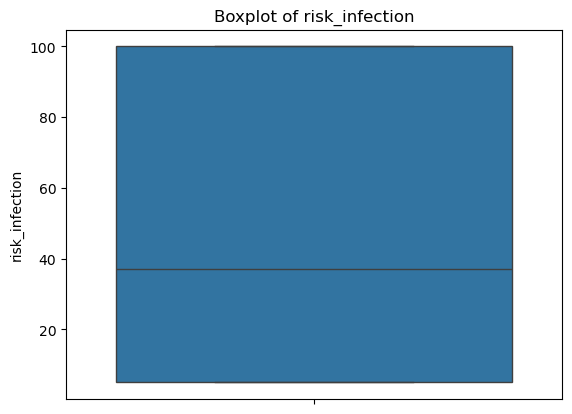

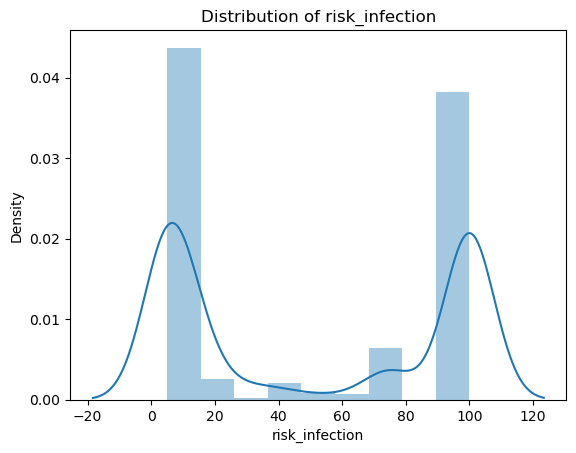

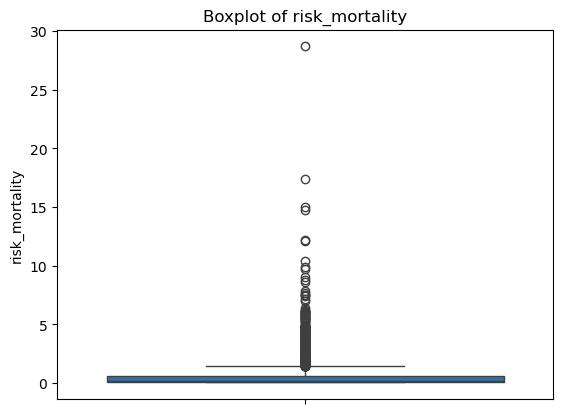

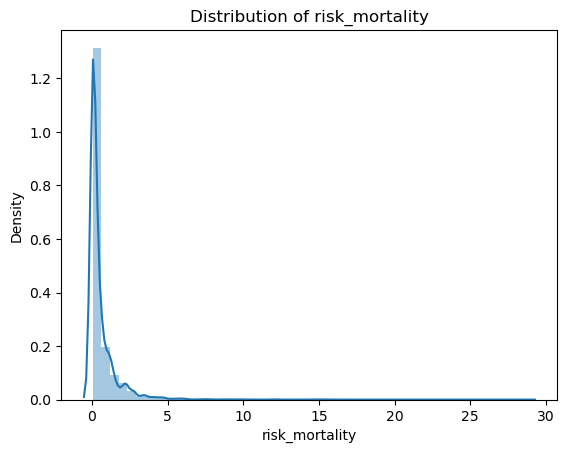

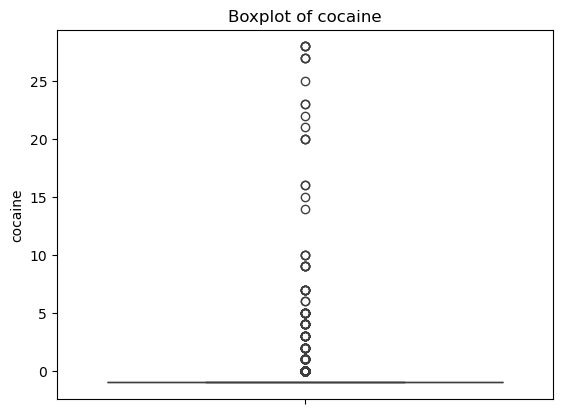

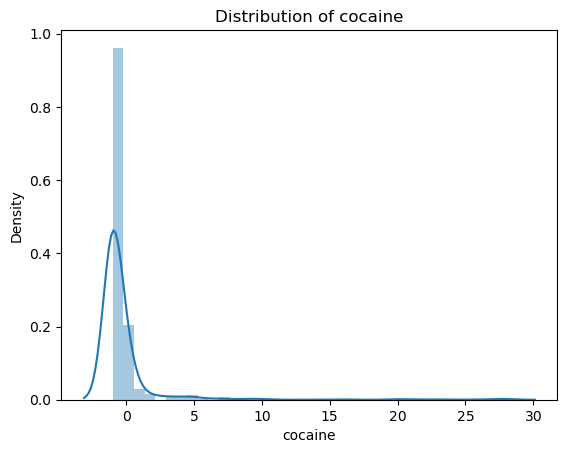

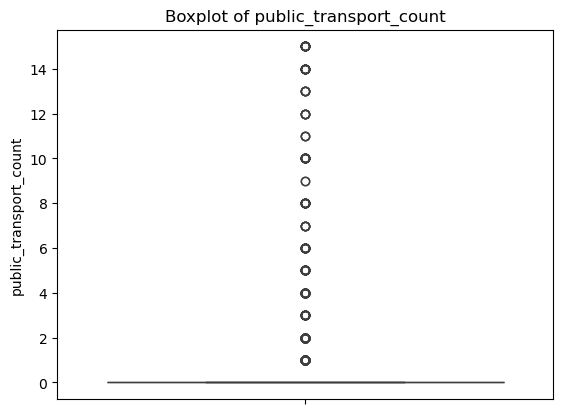

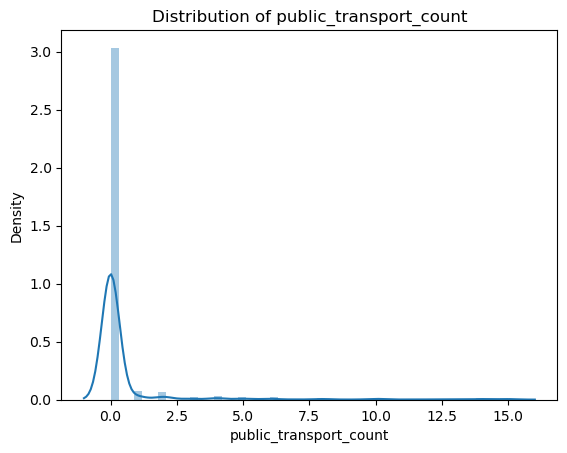

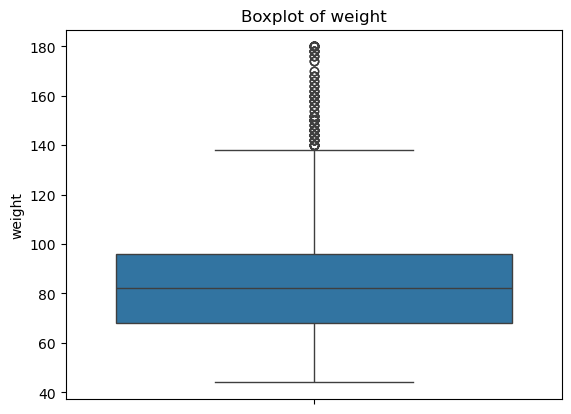

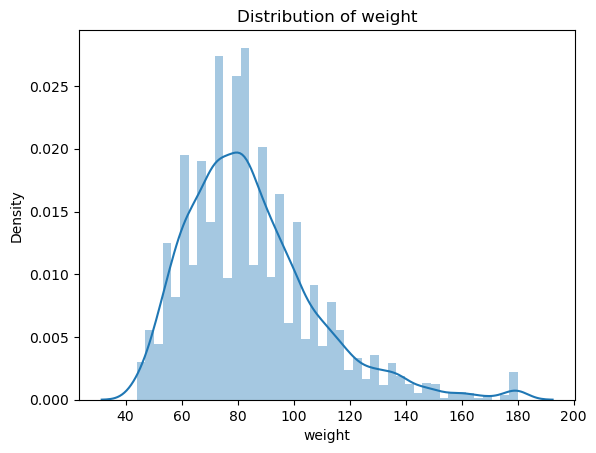

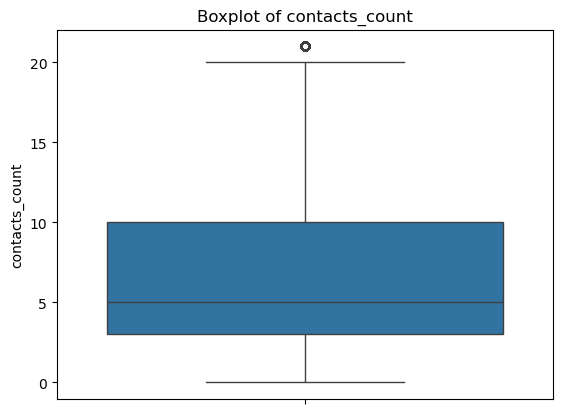

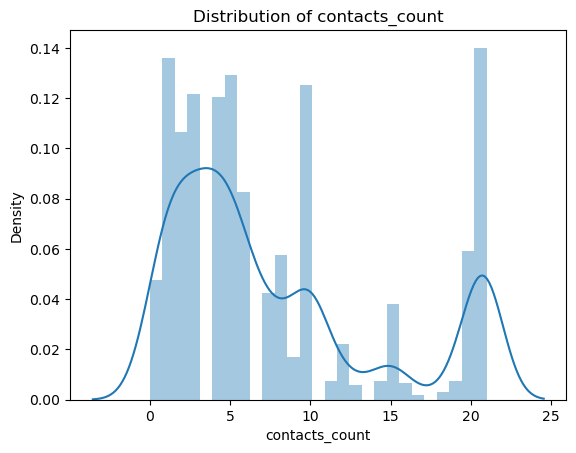

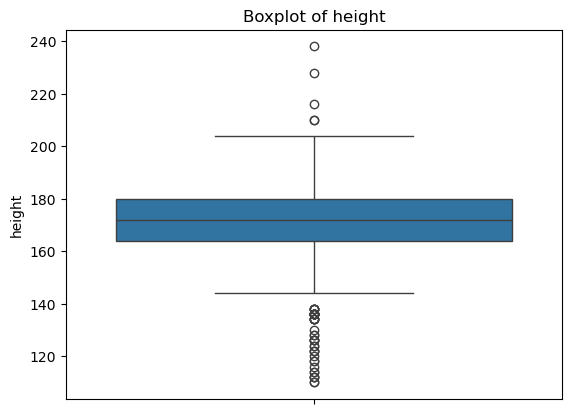

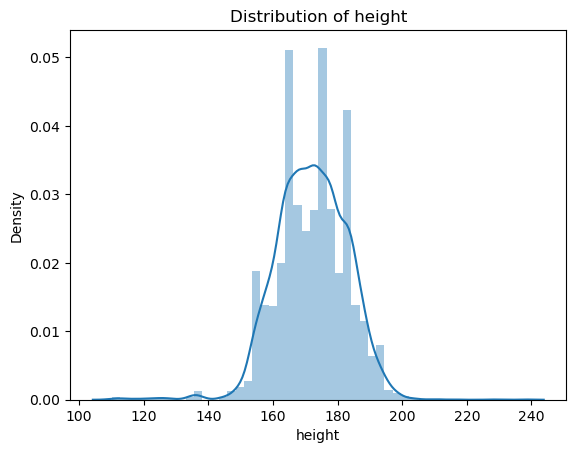

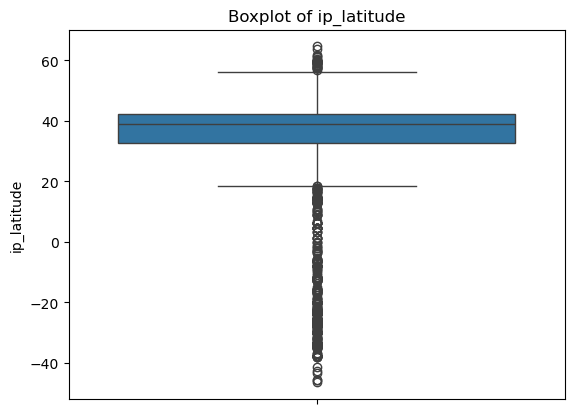

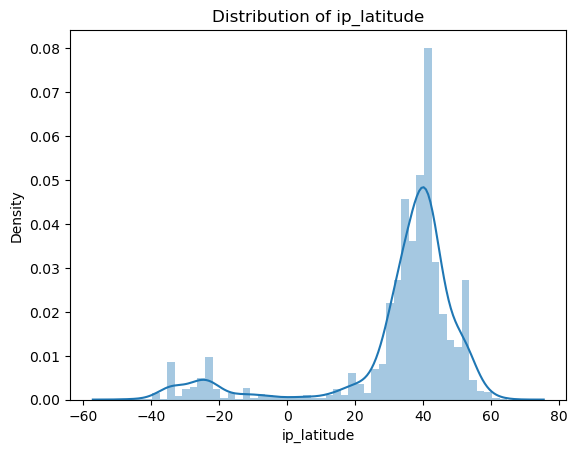

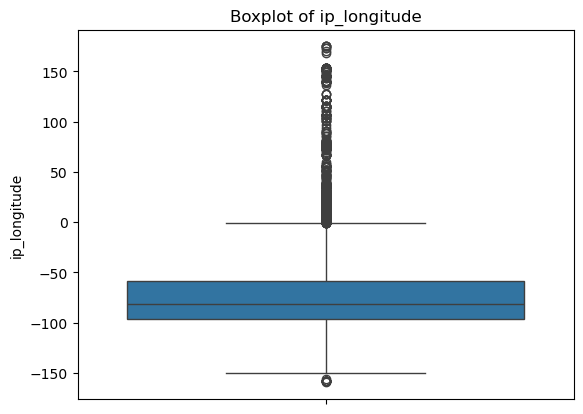

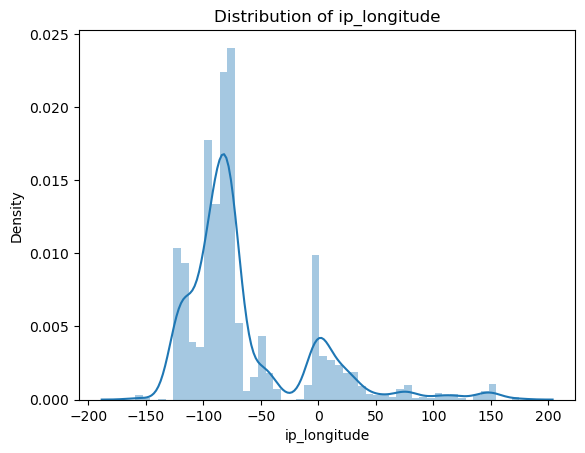

In [8]:
# outlier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

columns_to_plot = [
    'risk_infection', 'risk_mortality', 'cocaine', 'public_transport_count', 
    'weight', 'contacts_count', 'height', 'ip_latitude', 'ip_longitude'
]

for col in columns_to_plot:
    # Boxplot
    ax = sns.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()
    
    # Distplot
    dg = sns.distplot(df[col])
    plt.title(f'Distribution of {col}')
    plt.show()

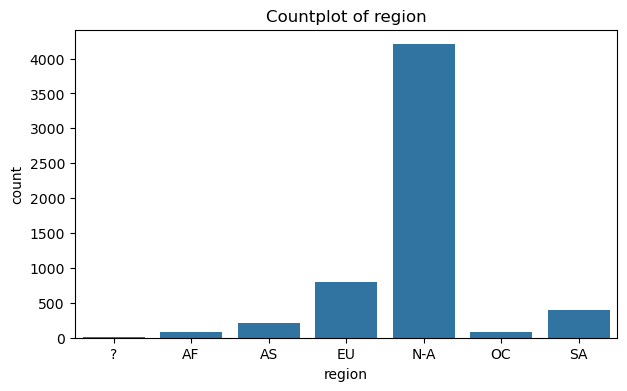

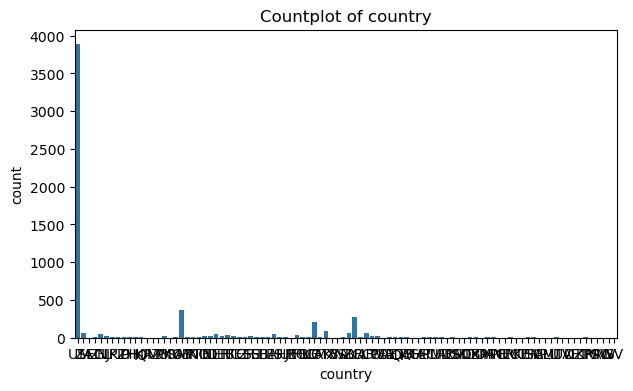

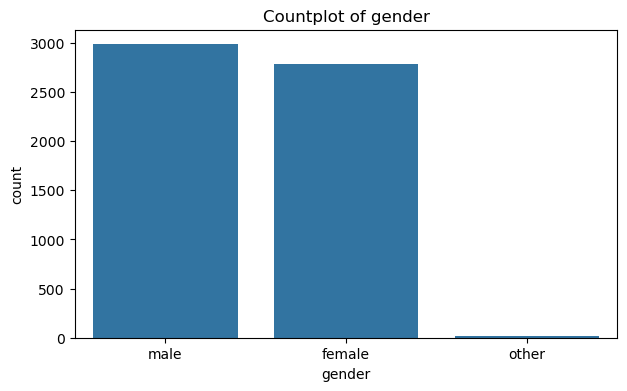

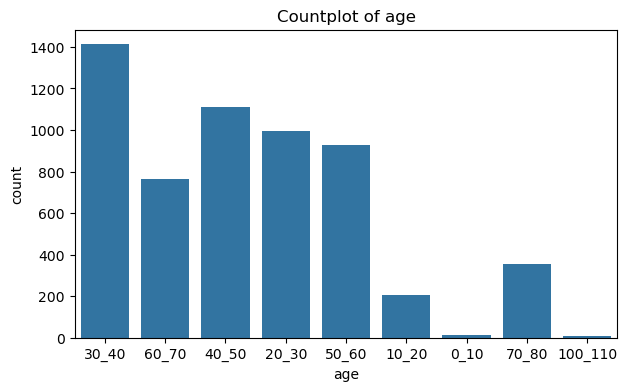

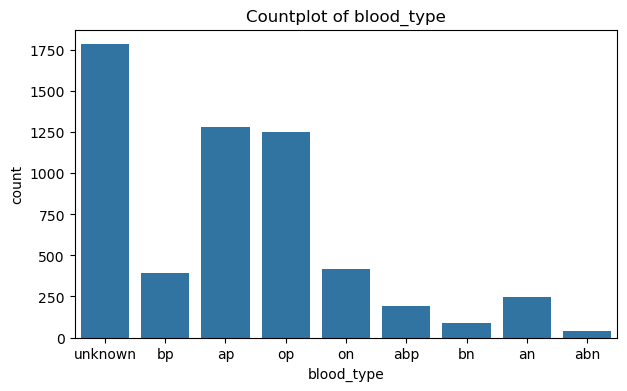

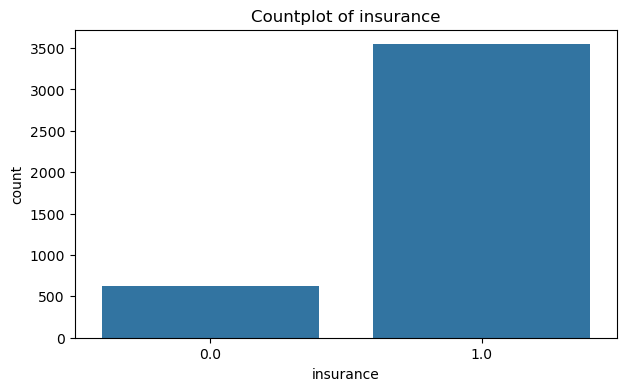

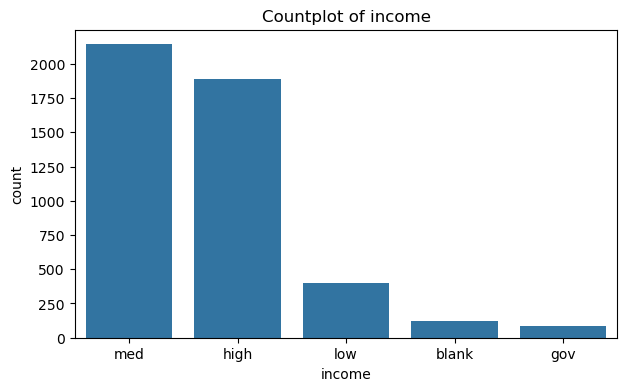

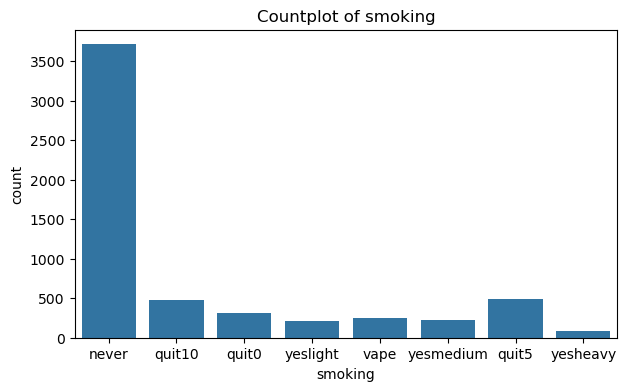

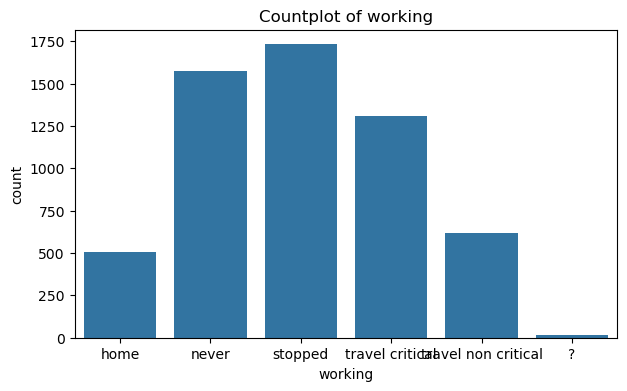

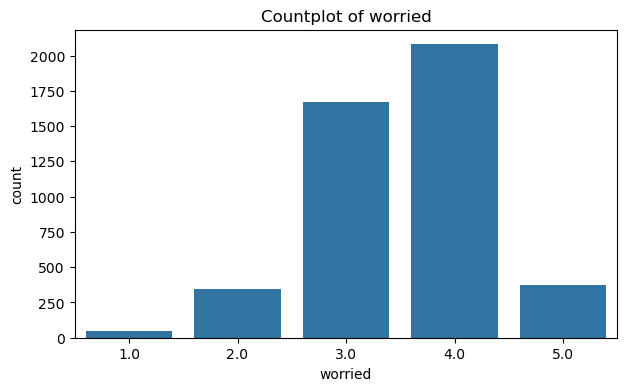

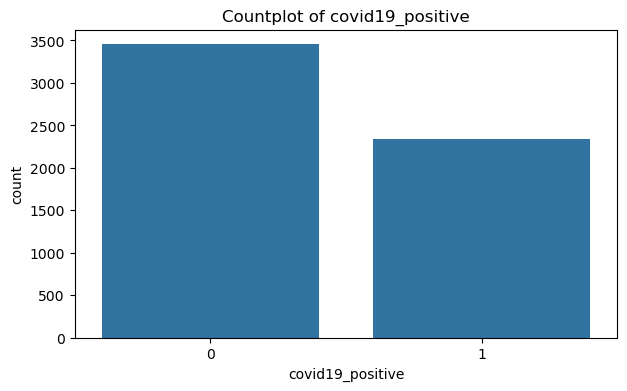

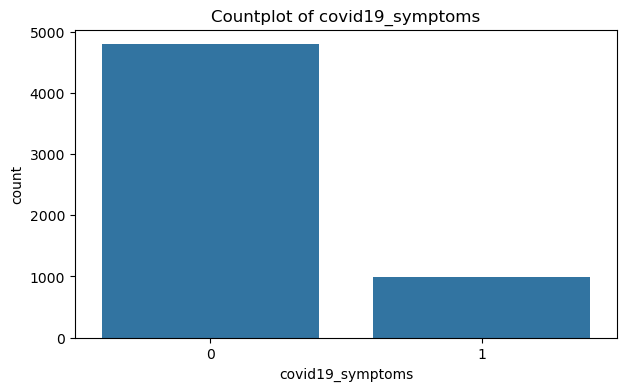

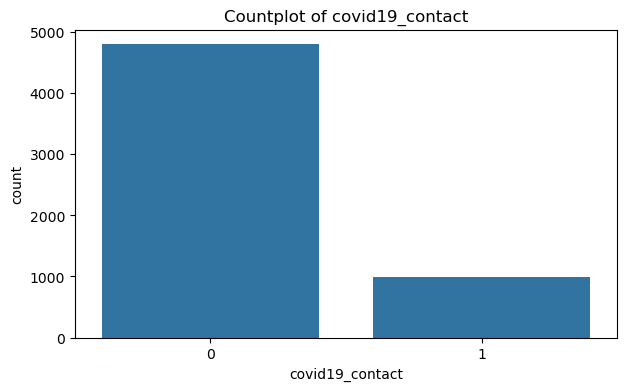

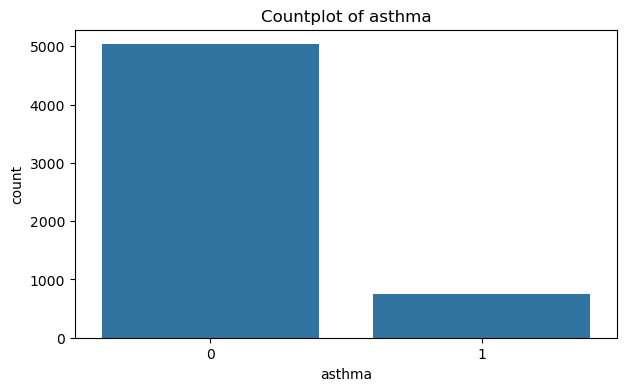

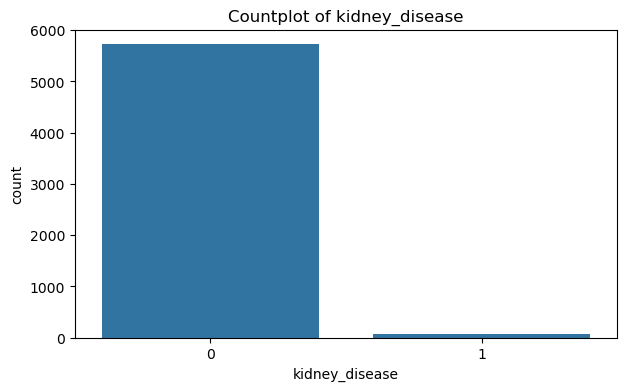

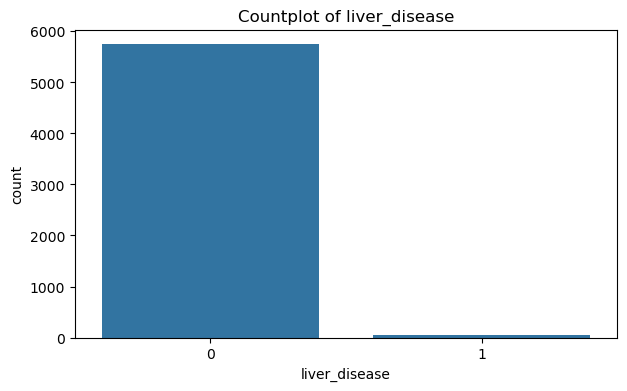

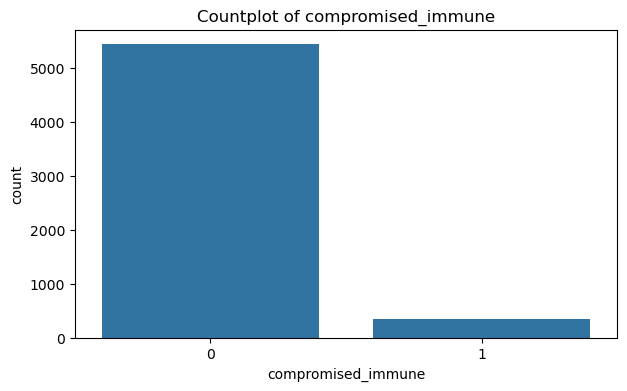

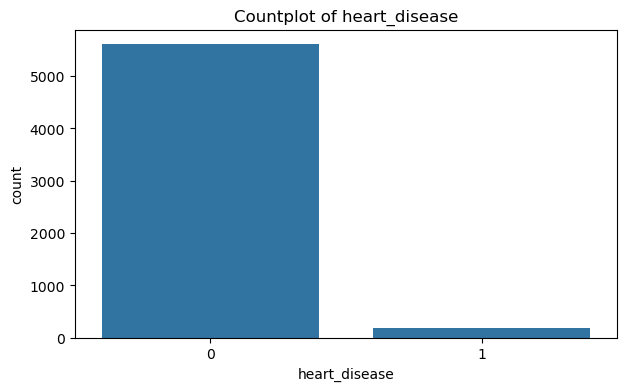

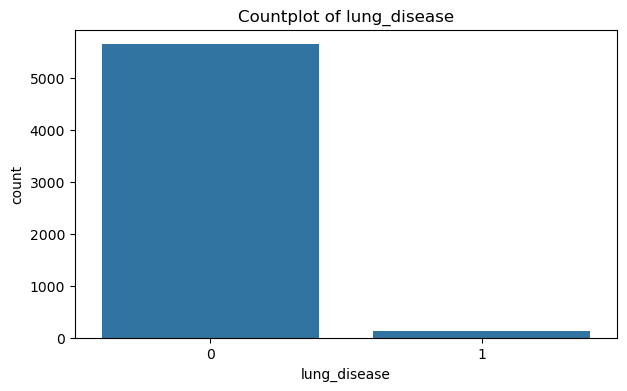

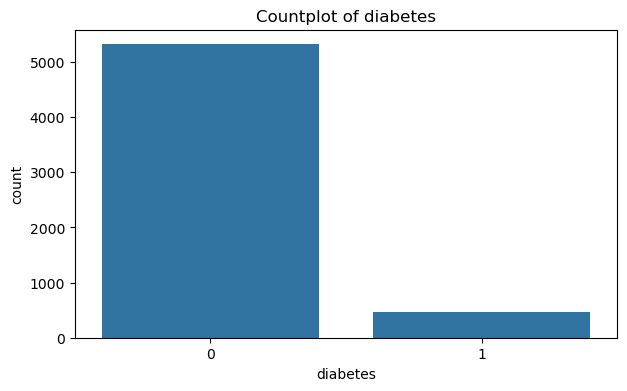

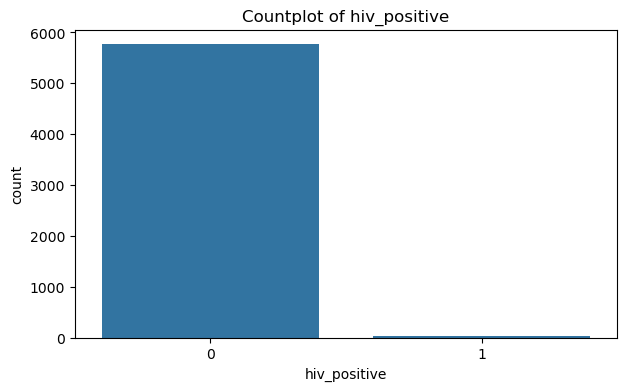

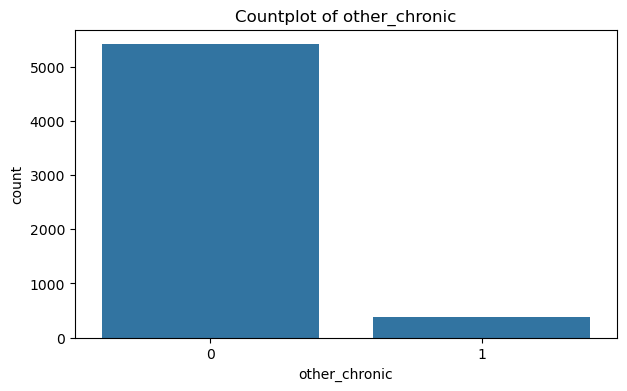

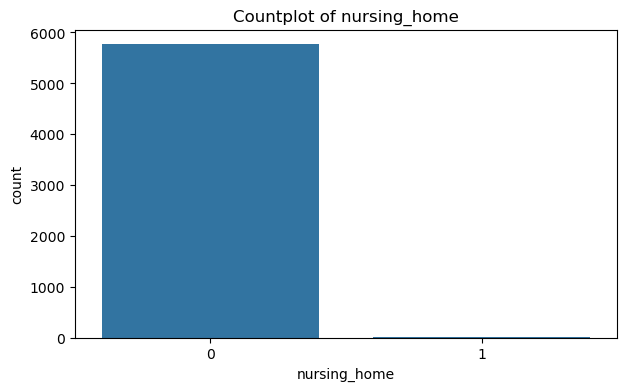

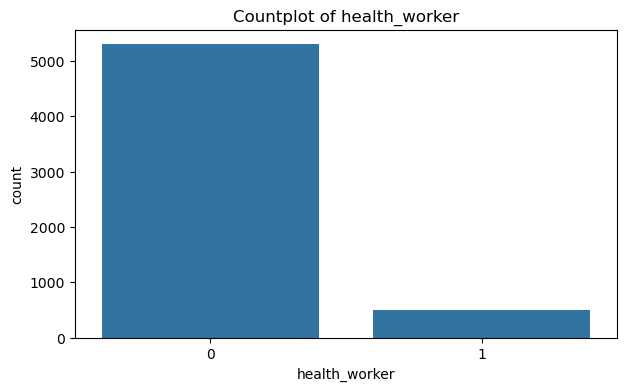

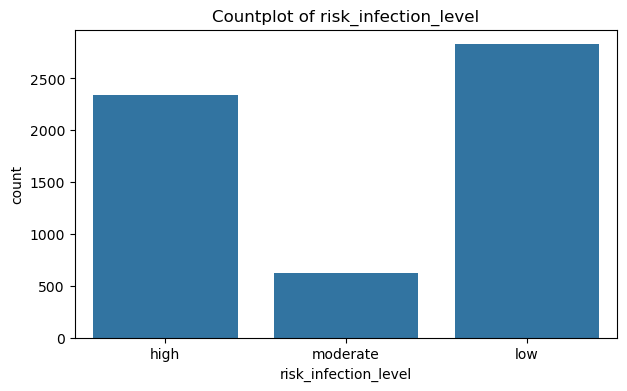

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['region', 'country', 'gender', 'age', 'blood_type',
        'insurance','income', 'smoking', 'working',
        'worried', 'covid19_positive', 'covid19_symptoms', 
        'covid19_contact', 'asthma', 'kidney_disease', 'liver_disease', 
        'compromised_immune', 'heart_disease', 'lung_disease', 'diabetes', 
        'hiv_positive', 'other_chronic', 'nursing_home', 'health_worker', 'risk_infection_level']

for col in cols:
    plt.figure(figsize=(7,4))
    sns.countplot(x=col, data=df)
    plt.title(f'Countplot of {col}')
    plt.show()

In [10]:
#5 Answer the following question
# (a) the average contacts_count of a patient from the US who is Covid-19 positive
avg_contacts_us = df[(df['country']=='US') & (df['covid19_positive']==1)]['contacts_count'].mean()
print("Average contacts_count of US COVID-19 positive patients: ", avg_contacts_us)

Average contacts_count of US COVID-19 positive patients:  8.24438902743142


In [11]:
# (b) which country has the highest number of 'Covid19-positive'
positive_number = df[df['covid19_positive']==1].groupby(['country'])['covid19_positive'].value_counts()
print(positive_number.sort_values(ascending=False))

country  covid19_positive
US       1                   1627
BR       1                    164
GB       1                    132
CA       1                     61
MX       1                     40
                             ... 
PS       1                      1
TH       1                      1
SK       1                      1
SG       1                      1
UA       1                      1
Name: count, Length: 73, dtype: int64


In [12]:
# (c) How many health workers in the dataset? and how many of them are covid19 positive?
print(df.groupby(['health_worker'])['covid19_positive'].value_counts())

health_worker  covid19_positive
0              0                   3146
               1                   2153
1              0                    308
               1                    182
Name: count, dtype: int64


In [13]:
# (d) Which are the top-five countries according to the average mortality risk?
mortality_mean = df.groupby(['country'])['risk_mortality'].mean()
print(mortality_mean.head(5))

country
AD    3.9940
AE    0.2391
AM    1.9235
AR    0.2470
AT    0.3556
Name: risk_mortality, dtype: float64


## Task 3

In [14]:
import numpy as np
mask = df['contacts_count'] < 1
df.loc[mask, 'contacts_count'] = np.nan
print(df['contacts_count'].value_counts(dropna=False))

contacts_count
21.0    626
1.0     608
5.0     577
10.0    560
3.0     543
4.0     538
2.0     476
6.0     370
20.0    265
8.0     257
NaN     255
7.0     190
15.0    171
12.0     99
9.0      76
14.0     34
19.0     34
11.0     33
16.0     29
13.0     26
18.0     14
17.0      8
Name: count, dtype: int64


In [15]:
# Survey_date: NaT
df['survey_date'] = df['survey_date'].fillna(df['survey_date'].mode()[0])

# region: ?, NaN
df['region'] = df['region'].replace('?', np.nan)
df['region']= df['region'].fillna(df['region'].mode()[0])

#country: Nan
df['country'] = df['country'].fillna(df['country'].mode()[0])

# worried: NaN
df['worried'] = df['worried'].fillna(df['worried'].median())

# working: ?, NaN
df['working'] = df['working'].replace('?', np.nan)
df['working'] = df['working'].fillna(df['working'].mode()[0])

# smoking: nan
df['smoking'] = df['smoking'].fillna(df['smoking'].mode()[0])

# cocaine: nan
df['cocaine']=df['cocaine'].fillna(df['cocaine'].median())

#contacts_count:nan
df['contacts_count']=df['contacts_count'].fillna(df['contacts_count'].median())

#public_transport_count:nan
df['public_transport_count']=df['public_transport_count'].fillna(df['public_transport_count'].median())

# blood type
df['blood_type'] = df['blood_type'].fillna('unknown')

# insurance 
df['insurance'] = df['insurance'].fillna(df['insurance'].mode()[0])


# income
df['income']=df['income'].replace('blank', np.nan)
df['income'] = df['income'].fillna('unknown')

In [16]:
missing_value = ['survey_date','region', 'country', 'worried','working', 'smoking', 'cocaine', 'contacts_count', 
                 'public_transport_count', 'blood_type', 'insurance', 'income']
for col in missing_value:
    print(f" After filling out the missing values of < {col} >, non-NaN count= ", df[col].count())

 After filling out the missing values of < survey_date >, non-NaN count=  5789
 After filling out the missing values of < region >, non-NaN count=  5789
 After filling out the missing values of < country >, non-NaN count=  5789
 After filling out the missing values of < worried >, non-NaN count=  5789
 After filling out the missing values of < working >, non-NaN count=  5789
 After filling out the missing values of < smoking >, non-NaN count=  5789
 After filling out the missing values of < cocaine >, non-NaN count=  5789
 After filling out the missing values of < contacts_count >, non-NaN count=  5789
 After filling out the missing values of < public_transport_count >, non-NaN count=  5789
 After filling out the missing values of < blood_type >, non-NaN count=  5789
 After filling out the missing values of < insurance >, non-NaN count=  5789
 After filling out the missing values of < income >, non-NaN count=  5789


In [17]:
for col in df.columns:
    print(f"\n======================{col}=======================")
    print(df[col].unique())
    print("\n --------------------------------------------------")


======================Participant_ID=======================
[862217754   2363592   2570172 ... 863671635 863783472 877539423]

 --------------------------------------------------

======================survey_date=======================
<DatetimeArray>
['2020-02-12 00:00:00', '2020-02-07 00:00:00', '2020-05-07 00:00:00',
 '2020-06-07 00:00:00', '2020-04-07 00:00:00', '2020-07-07 00:00:00',
 '2020-06-04 00:00:00', '2020-04-06 00:00:00', '2020-03-07 00:00:00',
 '2020-06-12 00:00:00', '2020-01-07 00:00:00', '2020-08-07 00:00:00',
 '2020-07-12 00:00:00', '2020-03-12 00:00:00', '2020-09-12 00:00:00',
 '2020-04-12 00:00:00', '2020-03-06 00:00:00', '2020-01-04 00:00:00',
 '2020-05-04 00:00:00', '2020-08-04 00:00:00', '2020-04-05 00:00:00',
 '2020-05-12 00:00:00', '2020-08-12 00:00:00', '2020-12-12 00:00:00',
 '2020-10-12 00:00:00', '2020-02-04 00:00:00', '2020-03-04 00:00:00',
 '2020-04-04 00:00:00', '2020-07-04 00:00:00', '2020-09-04 00:00:00',
 '2020-10-04 00:00:00', '2020-11-04 00:00:00',

In [18]:
outlier_cols = ['risk_mortality', 'weight', 'height']
# cocaine column have a lot of blank so outlier of this column cannot be removed

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1
    # conditional-outlier
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # imputation: median
    df.loc[(df[col]< lower_bound) | (df[col] > upper_bound), col] = np.nan
    df[col] = df[col].fillna(df[col].median())

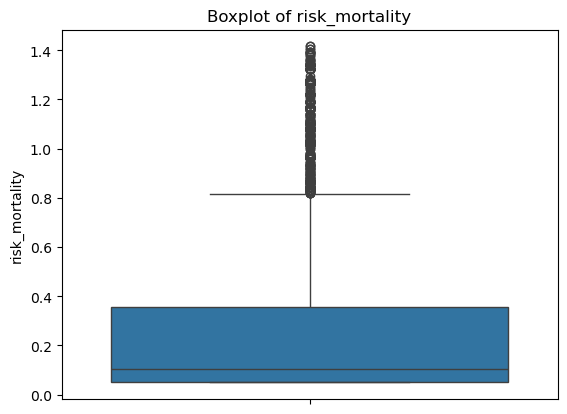

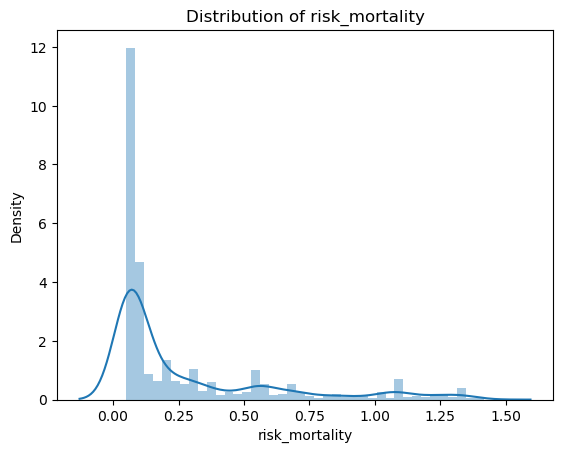

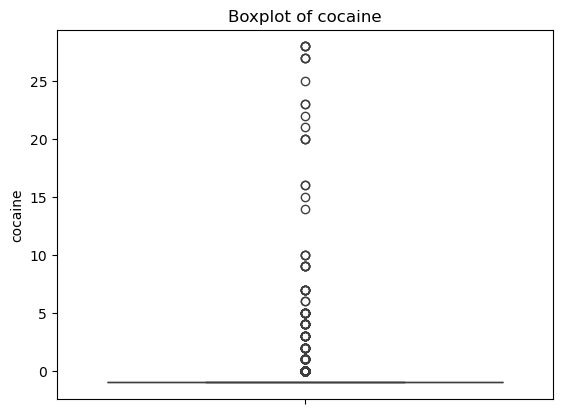

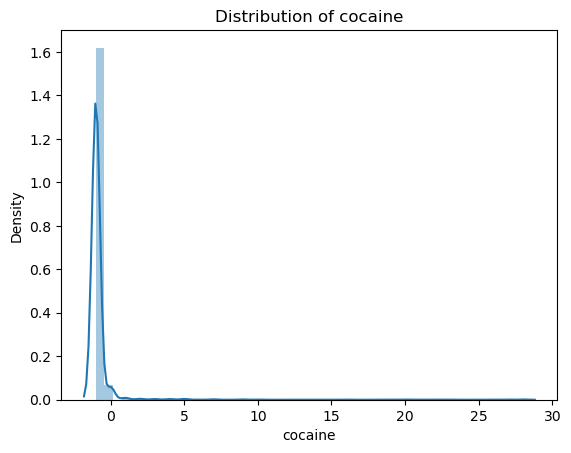

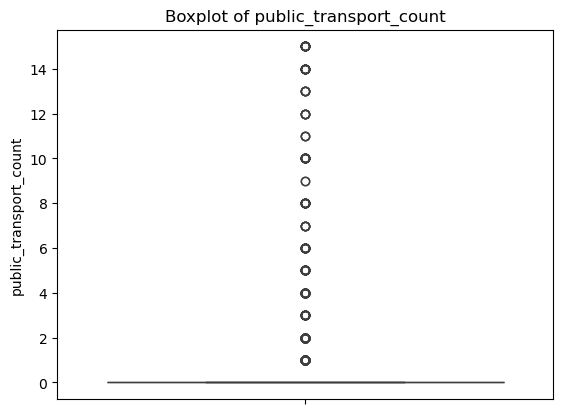

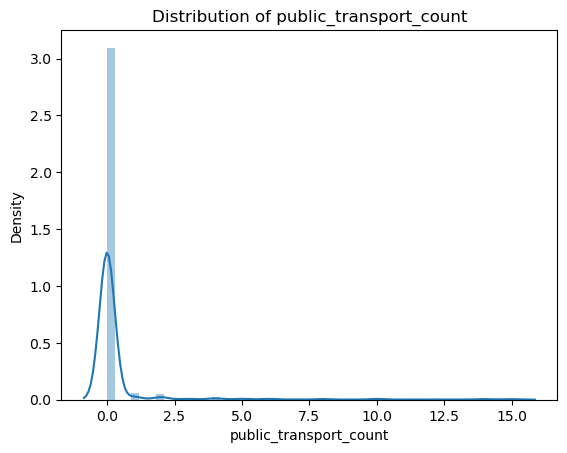

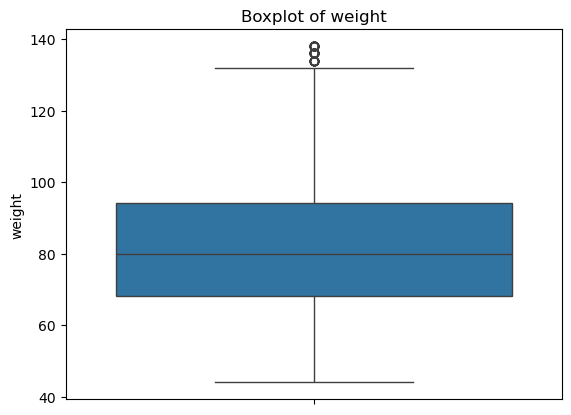

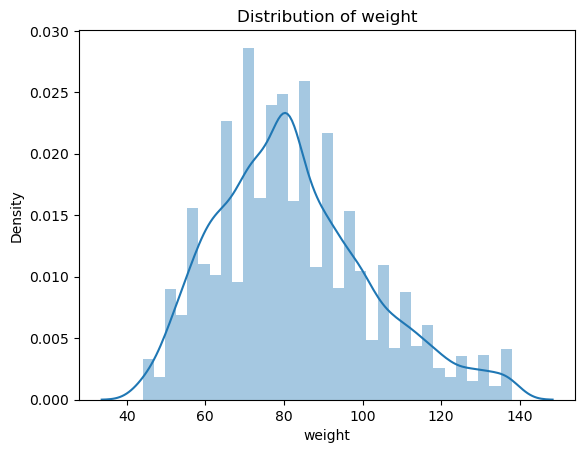

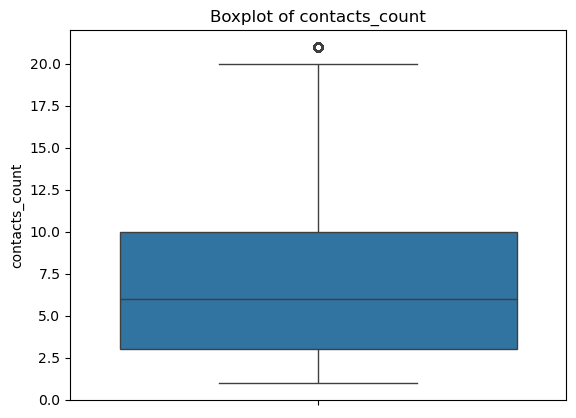

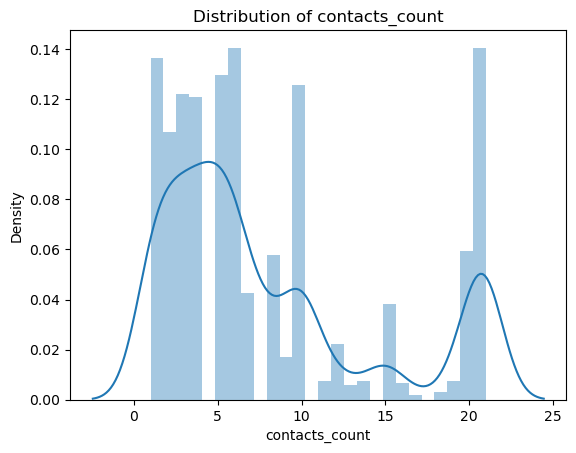

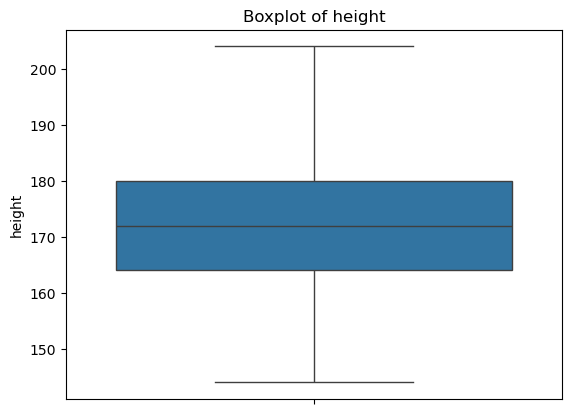

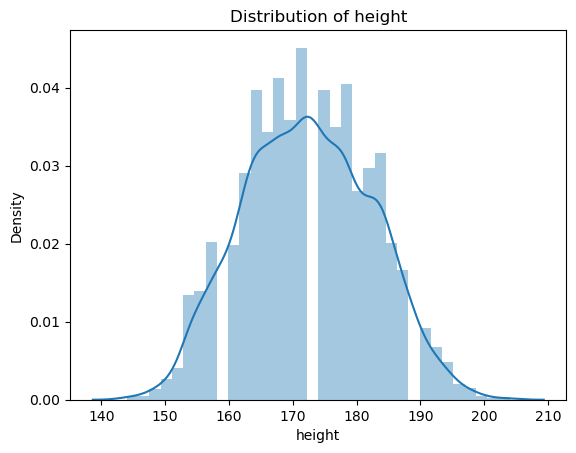

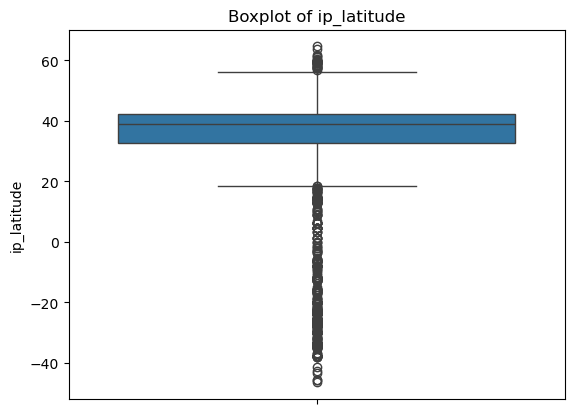

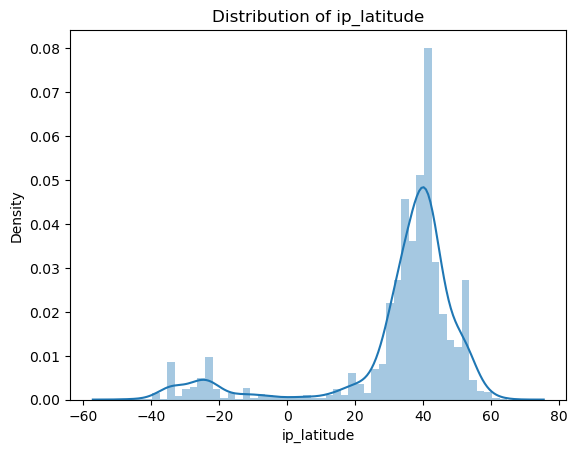

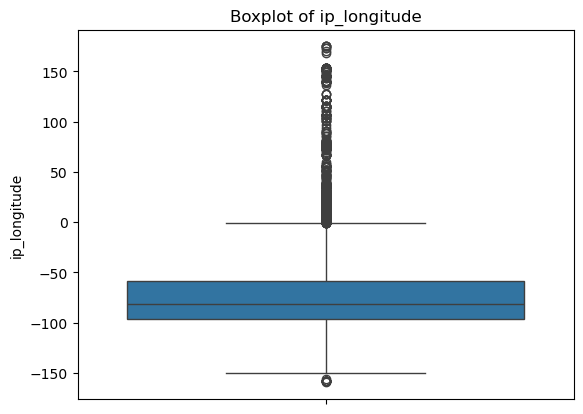

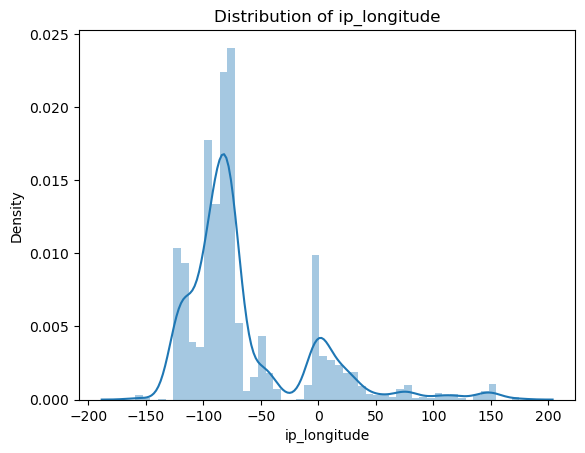

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

columns_to_plot = [
    'risk_mortality', 'cocaine', 'public_transport_count', 
    'weight', 'contacts_count', 'height', 'ip_latitude', 'ip_longitude'
]

for col in columns_to_plot:
    # Boxplot
    ax = sns.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()
    
    # Distplot
    dg = sns.distplot(df[col])
    plt.title(f'Distribution of {col}')
    plt.show()

In [20]:
# bmi_category: underweight, normal, overweight
def bmi_category(bmi):
    if bmi < 18.5:
        return 'underweight'
    elif bmi < 25:
        return 'normal'
    elif bmi < 30:
        return 'overweight'
    else:
        return 'obese'
df['bmi_category'] = df['bmi'].apply(bmi_category)

# exposure_count (contact count + transport count)
df['exposure_count'] = df['contacts_count'] + df['public_transport_count']

# smoking group
def smoking_category(x):
    if x in ['yeslight', 'vape', 'yesmedium', 'yesheavy']:
        return 'current'
    elif x in ['quit0', 'quit10', 'quit5']:
        return 'former'
    elif x in ['never']:
        return 'never'
    else:
        return 'unknown'
df['smoking_group'] = df['smoking'].apply(smoking_category)

# comorbidity
chronic_cols = ['asthma','kidney_disease', 'liver_disease', 'compromised_immune', 'heart_disease',
                'lung_disease', 'diabetes', 'hiv_positive', 'other_chronic' ]
df['underlying_disease']=df[chronic_cols].sum(axis=1)

In [21]:
derived_variables = ['bmi_category', 'exposure_count', 'smoking_group', 'underlying_disease']
for col in derived_variables:
    print(f"\n======================{col}=======================")
    print(df[col].unique())
    print("\n --------------------------------------------------")
    print(df[col].value_counts())
    print("\n --------------------------------------------------")


======================bmi_category=======================
['obese' 'normal' 'overweight' 'underweight']

 --------------------------------------------------
bmi_category
normal         2045
obese          1839
overweight     1806
underweight      99
Name: count, dtype: int64

 --------------------------------------------------

======================exposure_count=======================
[10.  6.  5.  4. 12.  3. 16.  8.  7.  9. 18. 11. 17. 15.  2. 20. 21.  1.
 23. 14. 31. 13. 19. 28. 35. 22. 34. 25. 26. 36. 24. 30. 33. 29. 27. 32.]

 --------------------------------------------------
exposure_count
6.0     618
1.0     584
21.0    567
5.0     562
3.0     535
10.0    519
4.0     514
2.0     461
8.0     265
20.0    240
7.0     209
15.0    164
12.0    110
9.0      89
11.0     52
14.0     45
16.0     38
19.0     33
13.0     32
18.0     28
17.0     17
23.0     15
36.0     13
22.0     12
25.0     10
34.0      9
31.0      9
28.0      7
27.0      7
24.0      5
35.0      4
26.0      4
30.0      

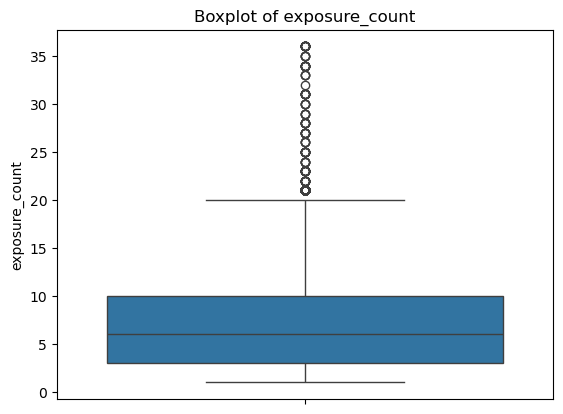

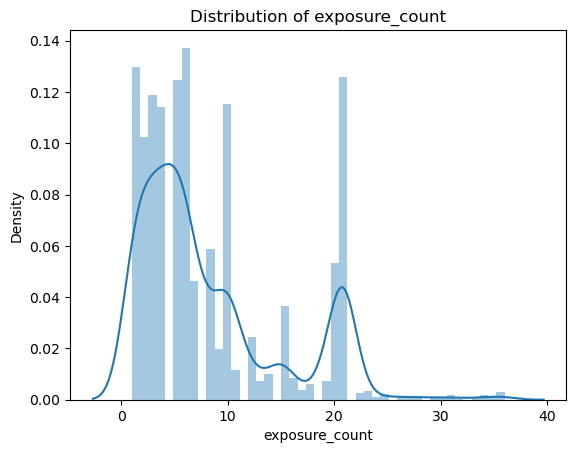

In [22]:
# Boxplot
ax = sns.boxplot(df['exposure_count'])
plt.title(f'Boxplot of exposure_count')
plt.show()
    
    # Distplot
dg = sns.distplot(df['exposure_count'])
plt.title(f'Distribution of exposure_count')
plt.show()


In [23]:
Q1 = df['exposure_count'].quantile(0.25)
Q3 = df['exposure_count'].quantile(0.75)

IQR = Q3 - Q1
    # conditional-outlier
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

    # imputation: median
df.loc[(df['exposure_count']< lower_bound) | (df['exposure_count'] > upper_bound), 'exposure_count'] = np.nan
df['exposure_count'] = df['exposure_count'].fillna(df['exposure_count'].median())

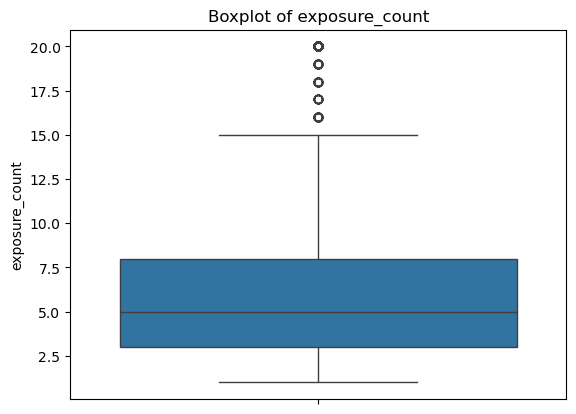

In [ ]:
# Boxplot
ax = sns.boxplot(df['exposure_count'])
plt.title(f'Boxplot of exposure_count')
plt.show()
    
    # Distplot
dg = sns.distplot(df['exposure_count'])
plt.title(f'Distribution of exposure_count')
plt.show()

In [ ]:
derived_variable_categorical = ['bmi_category', 'smoking_group', 'underlying_disease']
for col in derived_variable_categorical:
    plt.figure(figsize=(7,4))
    sns.countplot(x=col, data=df)
    plt.title(f'Countplot of {col}')
    plt.show()

In [ ]:
categorical_cols = ['gender', 'age', 'income', 'working', 'risk_infection_level',
                    'bmi_category', 'smoking_group','blood_type']

numeric_cols = ['height', 'weight', 'insurance', 'alcohol', 'cocaine',  'worried', 'risk_infection', 
                'risk_mortality', 'exposure_count', 'underlying_disease','covid19_positive', 'covid19_symptoms', 
                'covid19_contact', 'nursing_home', 'health_worker']

excluded_cols = ['region','country','Participant_ID','survey_date', 'smoking', 'bmi', 'asthma', 'contacts_count', 
                 'public_transport_count','kidney_disease', 'liver_disease', 'compromised_immune', 'heart_disease',
                'lung_disease', 'diabetes', 'hiv_positive', 'other_chronic', 'ip_latitude', 'ip_longitude']

df_dummies = pd.get_dummies(df[categorical_cols], drop_first=True)

In [ ]:
# after one hot encoding
df_dummies.head(10)

In [ ]:
print("Before:", len(categorical_cols))
print("After:", len(df_dummies.columns))

## Task 4

In [ ]:
all_columns = pd.concat([df_dummies, df[numeric_cols]],axis=1)

correlation_matrix = all_columns.corr()
plt.figure(figsize=(30,26))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, annot=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title('Correlation Matrix: All Variables', fontsize=19, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
df_grouped_covid = df_dummies.join(df['covid19_positive']).groupby('covid19_positive').mean()

print(df_grouped_covid)

In [ ]:
print("Before dropping columns, #columns = ", len(df.columns))

In [ ]:
df.drop(['country','Participant_ID','survey_date', 'region', 'smoking', 'bmi', 'asthma', 'contacts_count','public_transport_count',
         'kidney_disease', 'liver_disease', 'compromised_immune', 'heart_disease', 'lung_disease', 'diabetes', 'hiv_positive', 
         'other_chronic', 'ip_latitude', 'ip_longitude','height', 'weight','risk_infection', 'risk_infection_level'], axis=1, inplace=True)

In [ ]:
print("After dropping columns, #columns = ", len(df.columns))

In [ ]:
df = pd.get_dummies(df)

In [ ]:
y = df['covid19_positive'] # target
X = df.drop(['covid19_positive'], axis=1, inplace=False) # input

In [ ]:
from sklearn import preprocessing

x_vals = X.values

min_max_scaler = preprocessing.MinMaxScaler()
x_scaled = min_max_scaler.fit_transform(x_vals)

X_scaled = pd.DataFrame(x_scaled, columns=X.columns)
print(X_scaled.head())

In [ ]:
df[X.columns] = X_scaled
df.to_csv("Dataset-processed.csv", index=False)

## Task 5

In [ ]:
from sklearn.model_selection import train_test_split
rs = 10 # random state
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, stratify=y, random_state=rs)

print("Size of traning set:", len(X_train))
print("Size of testing set:", len(X_test))

In [ ]:
X_train

In [ ]:
y_train

### 5.1 Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

model = DecisionTreeClassifier(random_state=1)
model.fit(X_train, y_train)

In [ ]:
print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))

In [ ]:
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))

In [ ]:
print(classification_report(y_test, y_pred))

In [ ]:
print(model.get_params(deep = True))

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {'criterion': ['gini', 'entropy'],
          'max_depth': range(1, 10),
          'min_samples_leaf': range(0, 30, 10)[1:]}

grid_search = GridSearchCV(param_grid=params, estimator=DecisionTreeClassifier(random_state=rs))
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

In [ ]:
model = DecisionTreeClassifier(criterion='gini', max_depth=7, min_samples_leaf=20)
model.fit(X_train, y_train)
print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))

In [ ]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

### 5.2 KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

In [ ]:
y_pred_knn = knn.predict(X_test)

print("Train accuracy:", knn.score(X_train, y_train))
print("Test accuracy:", knn.score(X_test, y_test))

In [ ]:
print(classification_report(y_test, y_pred))

In [ ]:
print(confusion_matrix(y_test, y_pred))

In [ ]:
print(knn.get_params(deep = True))

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {'n_neighbors': range(1,10),
          'weights': ['uniform', 'distance'],
          'metric': ['euclidean', 'manhattan','minkowski']}

grid_search = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=params)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

In [ ]:
best_knn = KNeighborsClassifier(n_neighbors=9, weights='uniform', metric='manhattan')
best_knn.fit(X_train, y_train)

y_pred = best_knn.predict(X_test)

print("Train accuracy:", best_knn.score(X_train, y_train))
print("Test accuracy:", best_knn.score(X_test, y_test))

print(classification_report(y_test, y_pred))